In [ ]:
import pandas as pd
import numpy as np

# Konstanta global (konsisten utk reproducibility)
RANDOM_STATE = 42
PATH = "Transaction_Revesery.xlsx"   # sesuaikan kalau path Colab beda

# Load sheet pertama (sheet data transaksi)
df_raw = pd.read_excel(PATH, sheet_name=0)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Snapshot date = tanggal transaksi terakhir, jadi acuan definisi churn nanti
SNAPSHOT_DATE = df_raw['Date'].max()

print("Shape awal :", df_raw.shape)
print("Rentang tgl:", df_raw['Date'].min().date(), "->", df_raw['Date'].max().date())
print("Snapshot   :", SNAPSHOT_DATE.date())

Shape awal : (6799, 13)
Rentang tgl: 2025-10-10 -> 2026-06-27
Snapshot   : 2026-06-27


In [ ]:
# Potret kondisi mentah: tipe data, missing value, sebaran status
print("== INFO ==")
df_raw.info()

print("\n== MISSING VALUE per kolom ==")
print(df_raw.isnull().sum())

print("\n== STATUS ==")
print(df_raw['Status'].value_counts(dropna=False))

== INFO ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6799 entries, 0 to 6798
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           6799 non-null   datetime64[ns]
 1   Reference      6799 non-null   object        
 2   SKU            6799 non-null   object        
 3   Customer Name  6799 non-null   object        
 4   Email          6799 non-null   object        
 5   Gross Revenue  6799 non-null   int64         
 6   COGS           6799 non-null   int64         
 7   Net Revenue    6799 non-null   int64         
 8   % Margin       6799 non-null   int64         
 9   Account        4038 non-null   object        
 10  PIC            3979 non-null   object        
 11  UC             2644 non-null   object        
 12  Status         6785 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(8)
memory usage: 690.7+ KB

== MISSING VALUE per kolom ==
Date           

In [ ]:
df = df_raw.copy()

# Rapikan whitespace pada kolom teks
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()
df = df.replace({'nan': np.nan, 'None': np.nan})

# Log pembersihan biar transparan & bisa ditulis di skripsi
log = []
def bersihkan(kondisi, alasan):
    global df
    sebelum = len(df)
    df = df[kondisi].copy()
    log.append((alasan, sebelum - len(df), len(df)))

# 1. Duplikat baris penuh -> data ganda, tidak menambah informasi
sebelum = len(df); df = df.drop_duplicates()
log.append(("Hapus duplikat baris penuh", sebelum - len(df), len(df)))

# 2. Status kosong -> tidak bisa ditentukan berhasil/gagal, ambigu utk label
bersihkan(df['Status'].notna(), "Hapus Status kosong")

# 3. SKU '-' -> placeholder, bukan produk nyata
bersihkan(df['SKU'] != '-', "Hapus SKU '-' (placeholder)")

# 4. Reference 'TEST...' -> data uji coba sistem
bersihkan(~df['Reference'].astype(str).str.upper().str.startswith('TEST'),
          "Hapus Reference TEST")

# 5. Produk PPOB/non-subscription -> di luar scope (judul fokus akun subscription)
ppob_pat = r'PPOB|\bpln\b|dana|pulsa|flash|getcontact|lacak nomor|gopay|\bovo\b|shopeepay|\bisi\b|token'
bersihkan(~df['SKU'].astype(str).str.contains(ppob_pat, case=False, regex=True),
          "Hapus produk PPOB/non-subscription")

df = df.reset_index(drop=True)

# Tampilkan log
print(f"{'Langkah':42s} {'Dibuang':>8s} {'Sisa':>8s}")
for alasan, buang, sisa in log:
    print(f"{alasan:42s} {buang:8d} {sisa:8d}")
print(f"\nSKU tersisa ({df['SKU'].nunique()} produk):", sorted(df['SKU'].unique()))

Langkah                                     Dibuang     Sisa
Hapus duplikat baris penuh                        1     6798
Hapus Status kosong                              14     6784
Hapus SKU '-' (placeholder)                      93     6691
Hapus Reference TEST                              1     6690
Hapus produk PPOB/non-subscription              296     6394

SKU tersisa (13 produk): ['Canva Pro', 'Capcut Premium Mobile', 'Disney+ Premium', 'Google AI', 'HBO Max Premium', 'IQIYI Premium', 'Netflix Premium', 'Prime Video', 'Spotify Premium', 'Vidio Platinum', 'Viu Premium', 'WeTV Premium', 'YouTube Premium']


In [ ]:
# Penyamaran angka finansial rahasia: jitter ±5% reproducible.
# Tujuan: nominal asli tidak bocor, tapi struktur & rank antar-transaksi terjaga.
# Net Revenue & % Margin dihitung ULANG dari angka tersamarkan agar tetap konsisten.
rng = np.random.default_rng(RANDOM_STATE)
faktor = rng.uniform(0.95, 1.05, size=len(df))

df['Gross Revenue'] = (df['Gross Revenue'] * faktor).round(-2).astype(int)  # bulat ke ratusan
df['COGS']          = (df['COGS']          * faktor).round(-2).astype(int)
df['Net Revenue']   = df['Gross Revenue'] - df['COGS']
df['% Margin']      = np.where(df['Gross Revenue'] > 0,
                               (df['Net Revenue'] / df['Gross Revenue'] * 100).round(1), 0)

assert (df['Net Revenue'] == df['Gross Revenue'] - df['COGS']).all(), "Konsistensi finansial gagal!"
print("Penyamaran OK — konsistensi Net = Gross - COGS terjaga.")

Penyamaran OK — konsistensi Net = Gross - COGS terjaga.


In [ ]:
print("Shape akhir          :", df.shape)
print("Status               :", dict(df['Status'].value_counts()))
print("Pelanggan unik (all) :", df['Email'].nunique())
print("Pelanggan unik (PAID):", df[df['Status']=='PAID']['Email'].nunique())
print("\nMissing tersisa (kolom operasional, sengaja tidak diimputasi):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# df ini = data transaksi bersih (PAID + EXPIRED), dasar utk tahap berikutnya
df.head()

Shape akhir          : (6394, 13)
Status               : {'PAID': np.int64(4529), 'EXPIRED': np.int64(1865)}
Pelanggan unik (all) : 3942
Pelanggan unik (PAID): 3254

Missing tersisa (kolom operasional, sengaja tidak diimputasi):
Account    2417
PIC        2476
UC         3799
dtype: int64


,Date,Reference,SKU,Customer Name,Email,Gross Revenue,COGS,Net Revenue,% Margin,Account,PIC,UC,Status
0,2026-06-27,INV20260627141F04,Netflix Premium,Andi Humairah,77andihumairah@gmail.com,131000,30800,100200,76.5,joelle174@koaflix.com,Koala,INV-260626-5865GZ-000,PAID
1,2026-06-27,INV2026062776E814,Netflix Premium,Oki Putra,giovanni.naoki@gmail.com,49700,33800,15900,32.0,albarfornetflix06@gmail.com,Fanda,AMD-xfpflzbt2bre,PAID
2,2026-06-27,INV20260627BCE801,Netflix Premium,Tjandra Boedjang,candra.bujang@gmail.com,51800,35200,16600,32.0,riesjj@freenet.de,Fanda,AMD-xfpflzbt2bre,PAID
3,2026-06-27,INV20260627340B2D,Netflix Premium,Nurgiyanto,nurgiantoo61@gmail.com,51000,34700,16300,32.0,Baginetf@yahoo.com,Fanda,AMD-xfpflzbt2bre,PAID
4,2026-06-27,INV202606272C4F8C,Netflix Premium,Hajime,akunyixuan@gmail.com,48000,28800,19200,40.0,ceasar477@koaflix.com,Koala,INV-260626-5865GZ-000,PAID


In [ ]:
# Estimasi berapa bulan tiap transaksi (1/2/3) dari tier harga per produk.
# Patokan = harga 1 bulan terkini; transaksi pra-7-Mar dipaksa 1 bln (fitur belum ada).
CUTOFF_MULTIBULAN = pd.Timestamp('2026-03-07')
HARI_PER_BULAN = 30

HARGA_1BULAN = {
    'Netflix Premium': 45000, 'YouTube Premium': 40000, 'Disney+ Premium': 47000,
    'HBO Max Premium': 40000, 'Capcut Premium Mobile': 55000, 'Prime Video': 40000,
    'Spotify Premium': 42000, 'Canva Pro': 14000, 'Viu Premium': 13000,
    'IQIYI Premium': 15000, 'WeTV Premium': 15000, 'Google AI': 40000,
    'Vidio Platinum': 35000,
}

def estimasi_bulan(row):
    # sebelum fitur multi-bulan aktif -> pasti 1 bulan
    if row['Date'] < CUTOFF_MULTIBULAN:
        return 1
    patokan = HARGA_1BULAN.get(row['SKU'], np.nan)
    if pd.isna(patokan) or patokan <= 0:
        return 1
    return int(np.clip(round(row['Gross Revenue'] / patokan), 1, 3))

df['bulan_dibeli'] = df.apply(estimasi_bulan, axis=1)

# Tanggal langganan habis = tanggal beli + (jumlah bulan x 30 hari).
# Dipakai utk definisi churn berbasis masa-aktif, bukan sekadar tanggal transaksi.
df['tanggal_kadaluarsa'] = df['Date'] + pd.to_timedelta(df['bulan_dibeli'] * HARI_PER_BULAN, unit='D')

print("Distribusi durasi:", dict(df[df['Status']=='PAID']['bulan_dibeli'].value_counts().sort_index()))
df[['Date','SKU','Gross Revenue','bulan_dibeli','tanggal_kadaluarsa']].head()

Distribusi durasi: {1: np.int64(4090), 2: np.int64(213), 3: np.int64(226)}


,Date,SKU,Gross Revenue,bulan_dibeli,tanggal_kadaluarsa
0,2026-06-27,Netflix Premium,131000,3,2026-09-25
1,2026-06-27,Netflix Premium,49700,1,2026-07-27
2,2026-06-27,Netflix Premium,51800,1,2026-07-27
3,2026-06-27,Netflix Premium,51000,1,2026-07-27
4,2026-06-27,Netflix Premium,48000,1,2026-07-27


In [ ]:
paid = df[df['Status'] == 'PAID'].copy()
exp  = df[df['Status'] == 'EXPIRED'].copy()

# Urutkan transaksi per pelanggan utk perhitungan jeda
paid = paid.sort_values(['Email', 'Date'])
g = paid.groupby('Email')

# Fitur RFM + perilaku. CATATAN: recency sengaja TIDAK dibuat -> hindari target leakage.
cust = pd.DataFrame({
    'jumlah_transaksi'      : g.size(),                          # frequency
    'total_belanja'         : g['Gross Revenue'].sum(),          # monetary total
    'rata_belanja'          : g['Gross Revenue'].mean().round(0),
    'tenure_hari'           : (g['Date'].max() - g['Date'].min()).dt.days,  # lama aktif (bukan recency)
    'produk_unik'           : g['SKU'].nunique(),
    'rata_bulan'            : g['bulan_dibeli'].mean().round(2),  # komitmen durasi
    'maks_bulan'            : g['bulan_dibeli'].max(),
    'total_bulan_langganan' : g['bulan_dibeli'].sum(),
})
cust['is_pelanggan_ulang'] = (cust['jumlah_transaksi'] >= 2).astype(int)
cust['is_multi_produk']    = (cust['produk_unik'] > 1).astype(int)
cust['pernah_multibulan']  = (cust['maks_bulan'] > 1).astype(int)

# Rata-rata jeda antar pembelian (ritme beli). One-timer tak punya jeda -> isi median repeater (netral)
paid['gap'] = (paid['Date'] - g['Date'].shift(1)).dt.days
cust['rata_jeda_hari'] = paid.groupby('Email')['gap'].mean()
med_gap = cust.loc[cust['is_pelanggan_ulang'] == 1, 'rata_jeda_hari'].median()
cust['rata_jeda_hari'] = cust['rata_jeda_hari'].fillna(med_gap).round(1)

# Produk yang paling sering dibeli (kategorikal -> di-encode nanti di Stage 3)
cust['produk_utama'] = g['SKU'].agg(lambda s: s.mode().iat[0])

# Sinyal friksi: jumlah & rasio transaksi GAGAL (EXPIRED) per pelanggan
cust = cust.join(exp.groupby('Email').size().rename('jumlah_gagal'))
cust['jumlah_gagal'] = cust['jumlah_gagal'].fillna(0).astype(int)
cust['rasio_gagal']  = (cust['jumlah_gagal'] /
                        (cust['jumlah_gagal'] + cust['jumlah_transaksi'])).round(3)

In [ ]:
# Tanggal langganan habis TERAKHIR tiap pelanggan
last_exp = g['tanggal_kadaluarsa'].max()
cust['hari_sejak_kadaluarsa'] = (SNAPSHOT_DATE - last_exp).dt.days

# CHURN = langganan terakhir sudah habis > 60 hari & belum beli lagi
cust['churn'] = (cust['hari_sejak_kadaluarsa'] > 60).astype(int)

# 'hari_sejak_kadaluarsa' HANYA untuk bikin label -> DIBUANG dari fitur (mencegah leakage)
cust = cust.drop(columns=['hari_sejak_kadaluarsa'])

print("Jumlah pelanggan :", len(cust))
print("Churn rate       :", round(cust['churn'].mean()*100, 1), "%")
print(cust['churn'].value_counts())
cust.head()

Jumlah pelanggan : 3254
Churn rate       : 24.6 %
churn
0    2452
1     802
Name: count, dtype: int64


,jumlah_transaksi,total_belanja,rata_belanja,tenure_hari,produk_unik,rata_bulan,maks_bulan,total_bulan_langganan,is_pelanggan_ulang,is_multi_produk,pernah_multibulan,rata_jeda_hari,produk_utama,jumlah_gagal,rasio_gagal,churn
Email,,,,,,,,,,,,,,,,
1001kosmetik@gmail.com,1,50000,50000.0,0,1,1.0,1,1,0,0,0,29.0,Netflix Premium,0,0.0,0
12tasransel@gmail.com,1,43800,43800.0,0,1,1.0,1,1,0,0,0,29.0,Prime Video,0,0.0,0
19sa.ayumayangsari@gmail.com,1,47700,47700.0,0,1,1.0,1,1,0,0,0,29.0,Netflix Premium,0,0.0,1
1r131l4n63r0@gmail.com,1,47500,47500.0,0,1,1.0,1,1,0,0,0,29.0,Netflix Premium,0,0.0,0
20.091.ilhamabdulaziz@gmail.com,1,47100,47100.0,0,1,1.0,1,1,0,0,0,29.0,Netflix Premium,0,0.0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score)

# Buang fitur KEMBAR yg sudah diwakili versi kontinu (biar SHAP nanti tidak terpecah):
#  - is_pelanggan_ulang  -> sudah diwakili 'jumlah_transaksi'
#  - is_multi_produk      -> sudah diwakili 'produk_unik'
#  - pernah_multibulan    -> sudah diwakili 'rata_bulan'
#  - maks_bulan           -> sudah diwakili 'rata_bulan' & 'total_bulan_langganan'
drop_redundan = ['is_pelanggan_ulang', 'is_multi_produk', 'pernah_multibulan', 'maks_bulan']
data = cust.drop(columns=drop_redundan).copy()

# Encode produk_utama (kategorikal) -> one-hot. Cuma belasan kategori, aman tanpa ledakan dimensi.
data = pd.get_dummies(data, columns=['produk_utama'], prefix='prod')

X = data.drop(columns=['churn'])
y = data['churn']
print("Jumlah fitur:", X.shape[1])

Jumlah fitur: 22


In [ ]:
# Stratified split 80/20 -> proporsi churn terjaga sama di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train {len(X_train)} (churn {y_train.mean():.1%}) | "
      f"Test {len(X_test)} (churn {y_test.mean():.1%})")

# Baseline RF. class_weight='balanced' -> kompensasi imbalance ringan (24,6% churn)
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred  = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]

# Evaluasi pakai metrik yg tepat utk imbalanced (accuracy saja menyesatkan)
print("Accuracy :", round(accuracy_score(y_test, pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))
print("\n", classification_report(y_test, pred,
      target_names=['Aktif (0)', 'Churn (1)'], digits=3))
print("Confusion matrix [baris=aktual, kolom=prediksi]:")
print(confusion_matrix(y_test, pred))

Train 2603 (churn 24.7%) | Test 651 (churn 24.6%)
Accuracy : 0.696
ROC-AUC  : 0.783

               precision    recall  f1-score   support

   Aktif (0)      0.855     0.719     0.781       491
   Churn (1)      0.420     0.625     0.503       160

    accuracy                          0.696       651
   macro avg      0.637     0.672     0.642       651
weighted avg      0.748     0.696     0.713       651

Confusion matrix [baris=aktual, kolom=prediksi]:
[[353 138]
 [ 60 100]]


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Grid ramping tapi representatif. Tiap parameter ada alasannya:
#  max_depth        -> batasi kedalaman, cegah overfitting
#  min_samples_leaf -> minimal sampel per daun, biar pohon tak hafalan
#  class_weight     -> dua varian penyeimbang kelas minoritas (churn)
grid = {
    'n_estimators'    : [300],
    'max_depth'       : [6, 10, None],
    'min_samples_leaf': [1, 5],
    'max_features'    : ['sqrt'],
    'class_weight'    : ['balanced', 'balanced_subsample'],
}

# 5-fold stratified CV -> hasil tuning tak overfit ke satu split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scoring='f1' -> optimasi ke F1 kelas churn (seimbang recall & precision),
# BUKAN accuracy yg menyesatkan di data imbalanced
gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    grid, scoring='f1', cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)

print("Parameter terbaik :", gs.best_params_)
print("F1 churn (CV)     :", round(gs.best_score_, 3))

best_rf = gs.best_estimator_   # model final, dipakai utk SHAP nanti

Parameter terbaik : {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
F1 churn (CV)     : 0.558


In [ ]:
pred  = best_rf.predict(X_test)
proba = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))
print("\n", classification_report(y_test, pred,
      target_names=['Aktif (0)', 'Churn (1)'], digits=3))
print("Confusion matrix [baris=aktual, kolom=prediksi]:")
print(confusion_matrix(y_test, pred))

Accuracy : 0.651
ROC-AUC  : 0.808

               precision    recall  f1-score   support

   Aktif (0)      0.910     0.597     0.721       491
   Churn (1)      0.398     0.819     0.536       160

    accuracy                          0.651       651
   macro avg      0.654     0.708     0.628       651
weighted avg      0.784     0.651     0.675       651

Confusion matrix [baris=aktual, kolom=prediksi]:
[[293 198]
 [ 29 131]]


In [ ]:
import shap

# TreeExplainer: optimal & eksak utk model berbasis pohon (Random Forest)
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# Ambil kontribusi utk kelas churn (=1). Robust thd beda versi shap:
if isinstance(shap_values, list):       # versi lama: list [kelas0, kelas1]
    shap_churn = shap_values[1]
elif shap_values.ndim == 3:             # versi baru: array (n, fitur, kelas)
    shap_churn = shap_values[:, :, 1]
else:
    shap_churn = shap_values

# Peringkat faktor global = rata-rata |SHAP|
importance = (pd.Series(np.abs(shap_churn).mean(0), index=X_test.columns)
              .sort_values(ascending=False))
print("Top faktor pendorong churn:")
print(importance.head(12).round(4))

Top faktor pendorong churn:
total_belanja            0.0884
rata_belanja             0.0656
prod_Netflix Premium     0.0457
total_bulan_langganan    0.0351
tenure_hari              0.0235
rata_bulan               0.0217
prod_Disney+ Premium     0.0100
prod_Canva Pro           0.0100
jumlah_transaksi         0.0092
produk_unik              0.0084
prod_YouTube Premium     0.0063
rata_jeda_hari           0.0063
dtype: float64


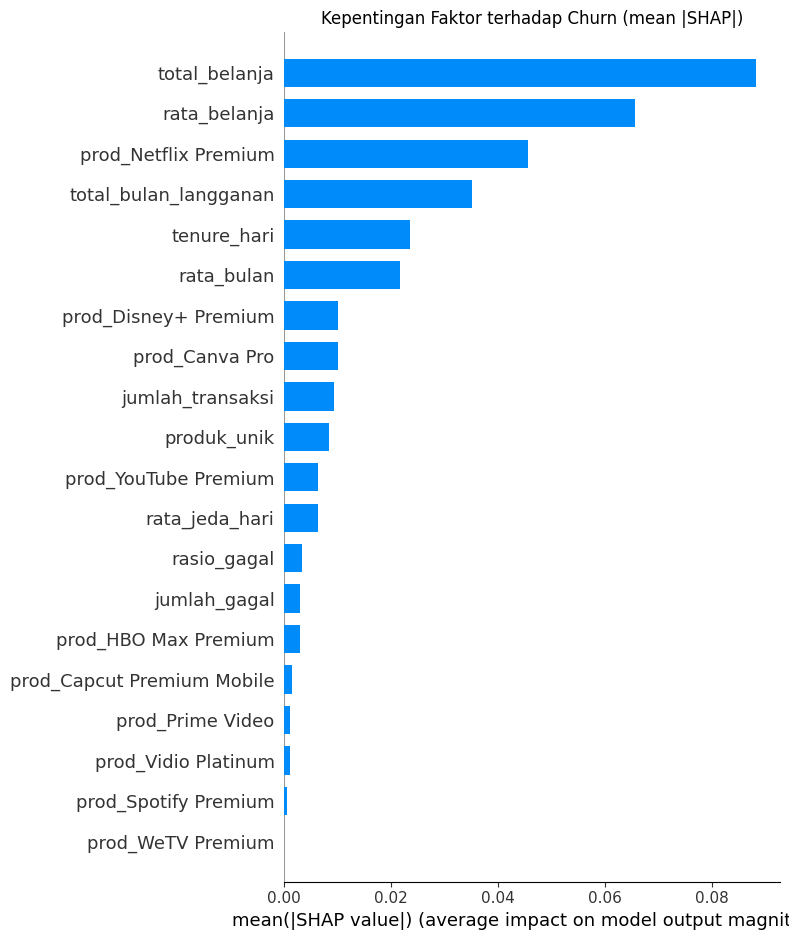

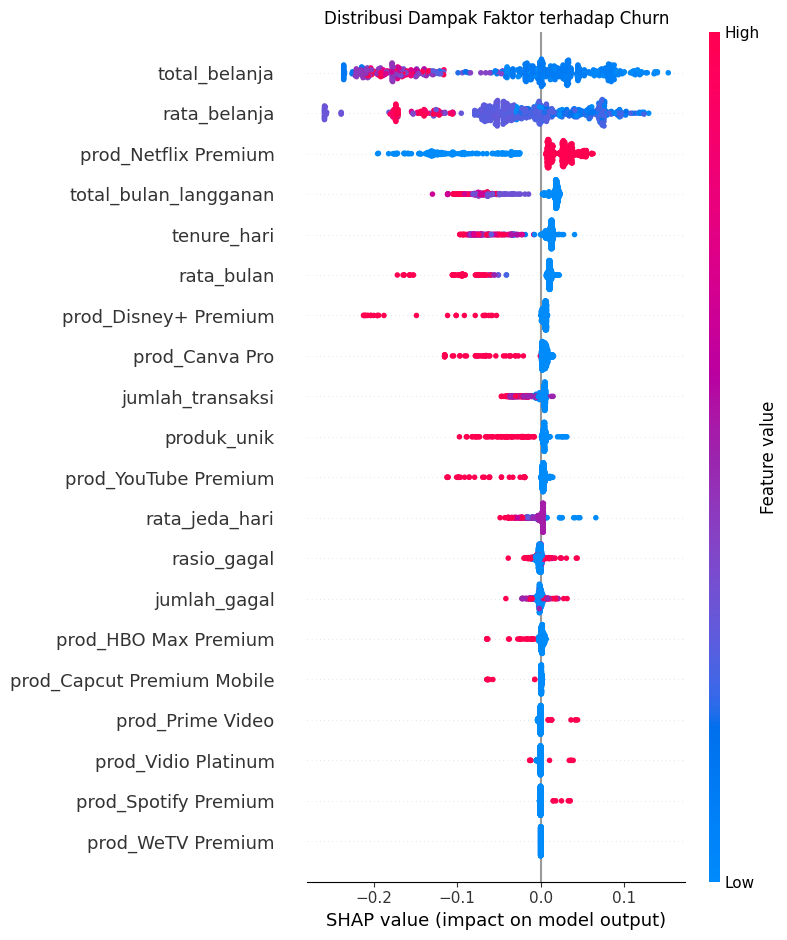

In [ ]:
import matplotlib.pyplot as plt

# 1) Bar plot -> ringkasan kepentingan faktor (paling jelas buat laporan)
shap.summary_plot(shap_churn, X_test, plot_type='bar', show=False)
plt.title('Kepentingan Faktor terhadap Churn (mean |SHAP|)')
plt.tight_layout(); plt.show()

# 2) Beeswarm -> arah & sebaran pengaruh tiap pelanggan
#    Merah = nilai fitur tinggi, Biru = rendah. Kanan = dorong churn, Kiri = dorong bertahan.
shap.summary_plot(shap_churn, X_test, show=False)
plt.title('Distribusi Dampak Faktor terhadap Churn')
plt.tight_layout(); plt.show()

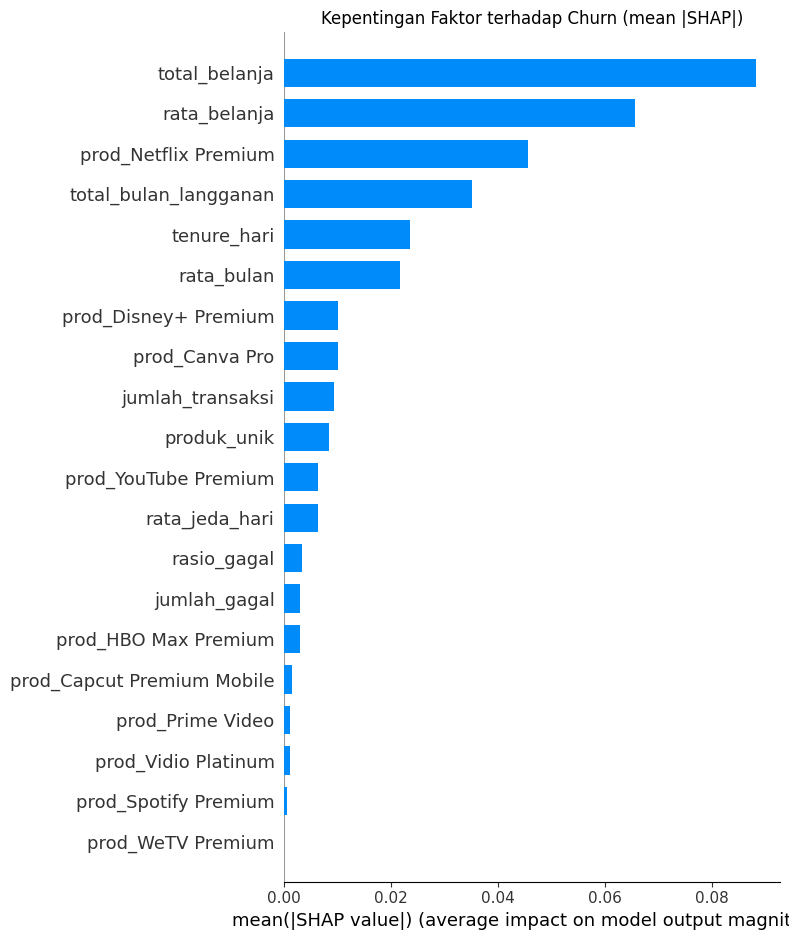

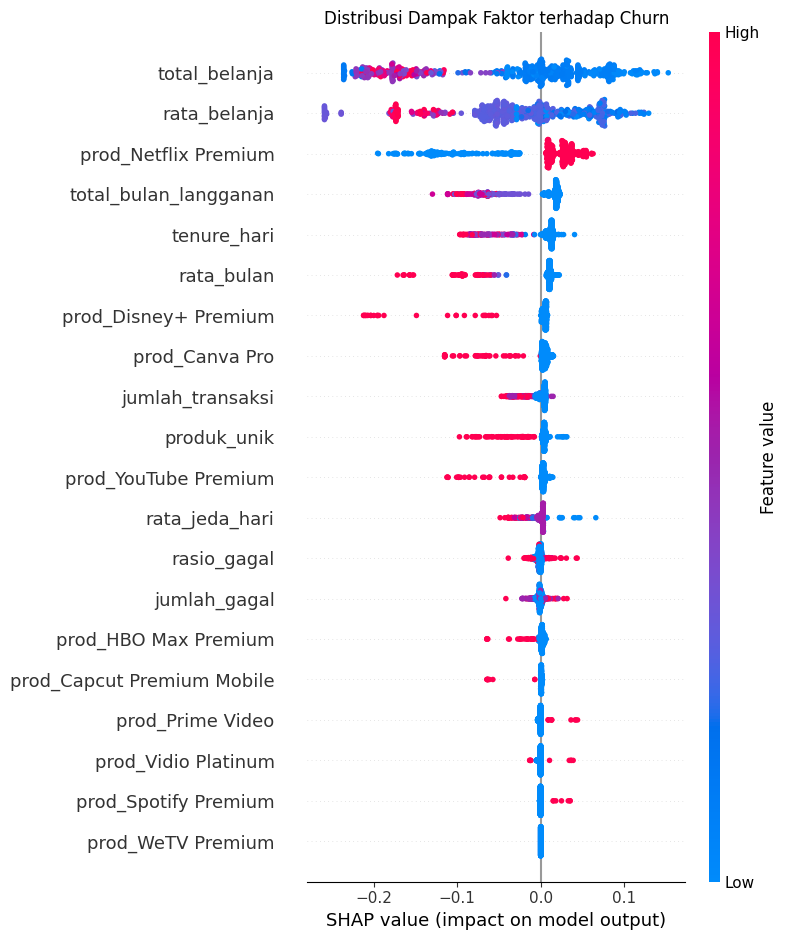

In [ ]:
import matplotlib.pyplot as plt

# --- 1) Bar plot ---
plt.figure()
shap.summary_plot(shap_churn, X_test, plot_type='bar', show=False)
plt.title('Kepentingan Faktor terhadap Churn (mean |SHAP|)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight')   # buat dilampir di skripsi
plt.show()

# --- 2) Beeswarm (terpisah, biar judul & sumbu tak ketabrak) ---
plt.figure()
shap.summary_plot(shap_churn, X_test, show=False)
plt.title('Distribusi Dampak Faktor terhadap Churn')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Korelasi nilai fitur vs SHAP-nya -> tentukan arah (positif=dorong churn)
cols = list(X_test.columns)
arah = []
for fitur in importance.head(8).index:
    corr = np.corrcoef(X_test[fitur], shap_churn[:, cols.index(fitur)])[0, 1]
    arah.append({'faktor': fitur, 'korelasi': round(corr, 2),
                 'arah': 'nilai tinggi → CHURN' if corr > 0 else 'nilai tinggi → BERTAHAN'})
pd.DataFrame(arah)

,faktor,korelasi,arah
0,total_belanja,-0.59,nilai tinggi → BERTAHAN
1,rata_belanja,-0.61,nilai tinggi → BERTAHAN
2,prod_Netflix Premium,0.91,nilai tinggi → CHURN
3,total_bulan_langganan,-0.71,nilai tinggi → BERTAHAN
4,tenure_hari,-0.82,nilai tinggi → BERTAHAN
5,rata_bulan,-0.92,nilai tinggi → BERTAHAN
6,prod_Disney+ Premium,-0.91,nilai tinggi → BERTAHAN
7,prod_Canva Pro,-0.92,nilai tinggi → BERTAHAN


 threshold  precision  recall    f1 churner_kena
      0.30      0.381   0.919 0.538      147/160
      0.35      0.379   0.894 0.533      143/160
      0.40      0.382   0.881 0.533      141/160
      0.45      0.396   0.856 0.542      137/160
      0.50      0.398   0.819 0.536      131/160
      0.55      0.437   0.688 0.534      110/160
      0.60      0.487   0.581 0.530       93/160
      0.65      0.578   0.463 0.514       74/160
      0.70      0.651   0.338 0.444       54/160
      0.75      0.687   0.287 0.405       46/160


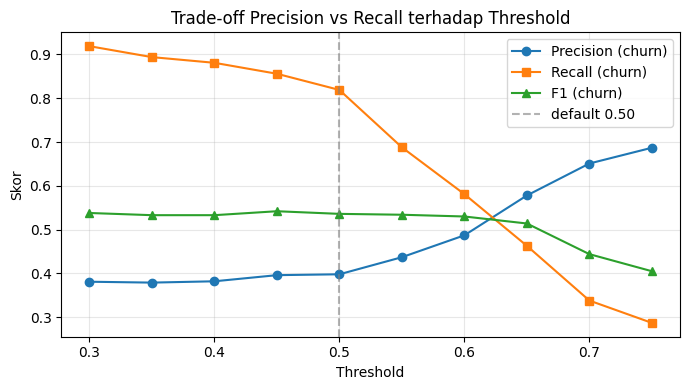

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

proba = best_rf.predict_proba(X_test)[:, 1]

rows = []
for t in np.arange(0.30, 0.76, 0.05):
    pred_t = (proba >= t).astype(int)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_test, pred_t, average='binary', pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, pred_t)
    rows.append({'threshold': round(t, 2), 'precision': round(pr, 3),
                 'recall': round(rc, 3), 'f1': round(f1, 3),
                 'churner_kena': f"{cm[1,1]}/{cm[1].sum()}"})
hasil = pd.DataFrame(rows)
print(hasil.to_string(index=False))

# Kurva trade-off precision vs recall terhadap threshold
plt.figure(figsize=(7,4))
plt.plot(hasil['threshold'], hasil['precision'], 'o-', label='Precision (churn)')
plt.plot(hasil['threshold'], hasil['recall'],    's-', label='Recall (churn)')
plt.plot(hasil['threshold'], hasil['f1'],        '^-', label='F1 (churn)')
plt.axvline(0.5, ls='--', c='gray', alpha=.6, label='default 0.50')
plt.xlabel('Threshold'); plt.ylabel('Skor'); plt.legend(); plt.grid(alpha=.3)
plt.title('Trade-off Precision vs Recall terhadap Threshold')
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=300, bbox_inches='tight'); plt.show()

# Terapkan threshold pilihan (contoh 0.45) untuk prediksi operasional
THRESHOLD = 0.45
pred_final = (proba >= THRESHOLD).astype(int)

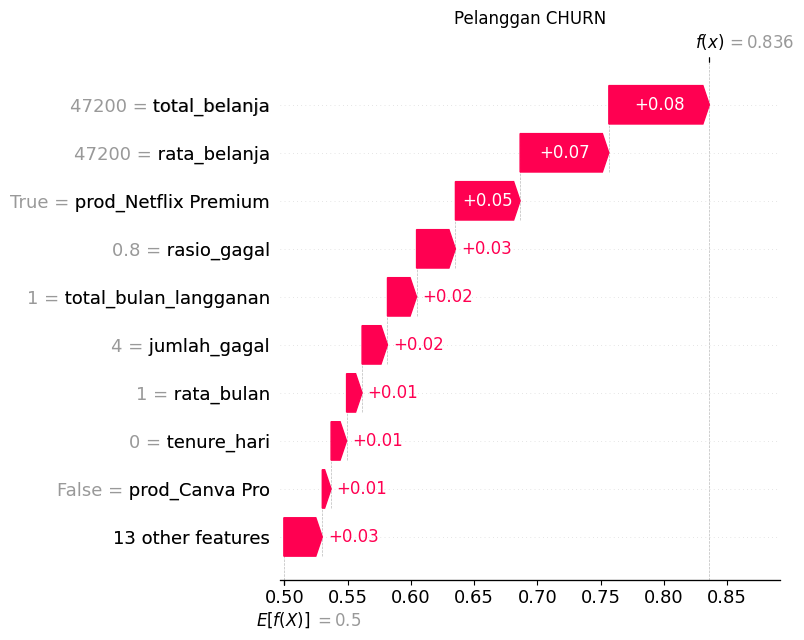

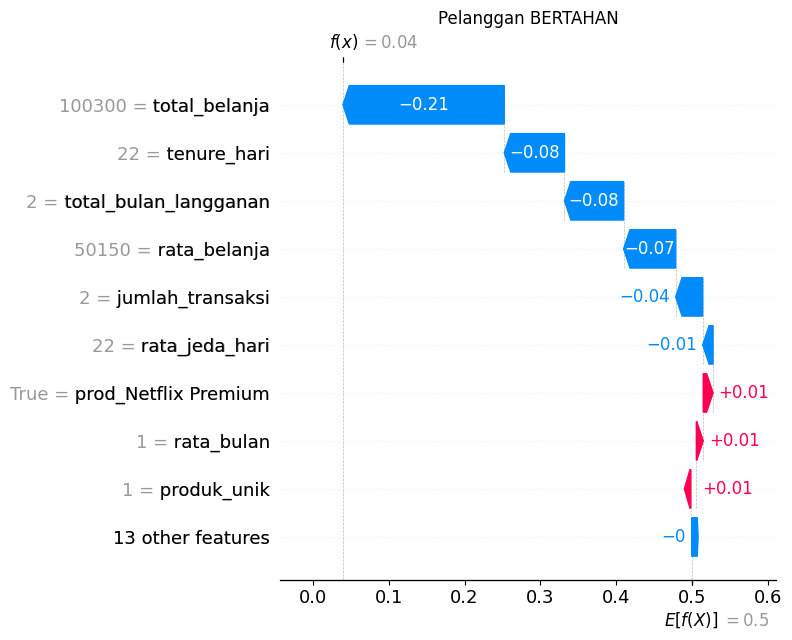

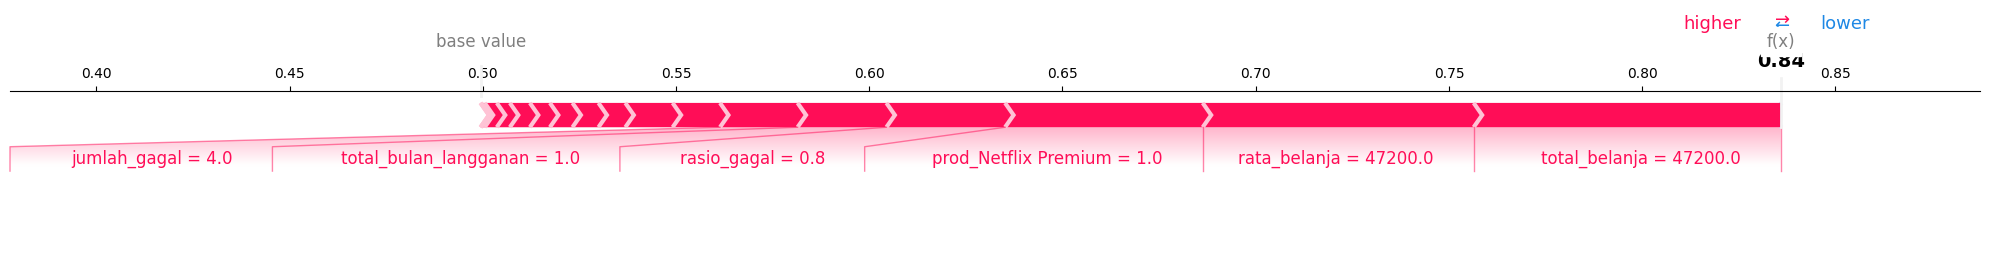

In [ ]:
# Nilai SHAP & base value (pastikan shap_churn sudah dihitung di Cell 11)
base = explainer.expected_value
base = base[1] if hasattr(base, '__len__') else base   # ambil base kelas churn

# Pilih 1 kasus jelas tiap kelas
idx_churn = np.where((y_test.values == 1) & (proba > 0.7))[0][0]
idx_stay  = np.where((y_test.values == 0) & (proba < 0.2))[0][0]

# --- Waterfall (paling rapi & gampang disimpan utk skripsi) ---
for idx, judul, fname in [(idx_churn, 'Pelanggan CHURN', 'shap_kasus_churn.png'),
                          (idx_stay,  'Pelanggan BERTAHAN', 'shap_kasus_bertahan.png')]:
    ex = shap.Explanation(values=shap_churn[idx], base_values=base,
                          data=X_test.iloc[idx], feature_names=X_test.columns.tolist())
    shap.plots.waterfall(ex, show=False)
    plt.title(judul)
    plt.tight_layout(); plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()

# --- Force plot klasik (versi interaktif/matplotlib), kalau mau bentuk ini ---
shap.force_plot(base, shap_churn[idx_churn], X_test.iloc[idx_churn],
                matplotlib=True, show=False)
plt.tight_layout(); plt.savefig('force_churn.png', dpi=300, bbox_inches='tight'); plt.show()

In [ ]:
cust.to_csv('analyzed_customer_data.csv', index=False)
print('Analyzed customer data exported to analyzed_customer_data.csv')